# Forman Profile: evolution across training checkpoints

## 1. Imports

In [1]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import scipy.sparse as sp
from scipy.stats import spearmanr, pearsonr, wasserstein_distance

## 2. Utility functions

In [2]:
# (Forman F-diagonal computation moved to run.py — eigenvalues are pre-computed and saved as .npy)

## 3. Config

In [ ]:
# ── config ─────────────────────────────────────────────────────────────────────
dataset         = "citeseer"   # change this to switch experiments
model           = "GeneralSheaf"
normalised      = "true"           # "true" or "false"
stalk_dim       = 5
layers          = 4
hidden_channels = 16
epochs          = 500
seed            = 43
num_folds       = 10

# map_type choices: 'identity', 'diag', 'bundle', 'general'  (only used for Joint models)
_JOINT_MODELS = {'JointSheafParams', 'JointSheafParamsAlt'}
map_type = 'identity'
map_tag  = f"_first_maps_{map_type}" if model in _JOINT_MODELS else ""

NUM_NODES = {
    "roman_empire":   22662,
    "minesweeper":    10000,
    "cora":           2708,
    "citeseer":       3327,
    "pubmed":         19717,
    "cornell":        183,
    "wisconsin":      251,
    "amazon_ratings": 24492,
    "questions":      48921,
    "tolokers":       11758,
}
num_nodes = NUM_NODES[dataset]
n, d = num_nodes, stalk_dim

BASE = (f"../results/forman_eigs/{dataset}/{model}{map_tag}/normalised-{normalised}/stalk_dim-{stalk_dim}/"
        f"{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs")

def eigs_path(layer, fold, ckpt_name):
    filename = f"{model}_{dataset}_layer{layer}_fold{fold}{map_tag}_seed{seed}.npy"
    if ckpt_name == 'last':
        return os.path.join(BASE, filename)
    return os.path.join(BASE, 'checkpoints', ckpt_name, filename)

def f0_top_path(fold):
    return os.path.join(BASE, f"f0_top_{dataset}_n{n}_fold{fold}_seed{seed}.npy")

# Discover checkpoints dynamically from disk — epoch-N sorted numerically, 'last' at end.
import re as _re

def _ckpt_sort_key(name):
    if name == 'last':
        return float('inf')
    m = _re.match(r'epoch-(\d+)', name)
    return int(m.group(1)) if m else float('inf') - 1

_ckpt_dir = os.path.join(BASE, 'checkpoints')
_found = []
if os.path.isdir(_ckpt_dir):
    _found = [e for e in os.listdir(_ckpt_dir) if os.path.isdir(os.path.join(_ckpt_dir, e))]
checkpoint_names = sorted(_found, key=_ckpt_sort_key) + ['last']
print(f"dataset={dataset}  model={model}  normalised={normalised}  d={d}  layers={layers}")
print(f"map_tag={map_tag!r}")
print(f"Checkpoints found: {checkpoint_names}")

# Load best_epochs.json if it exists.
best_epochs_json = os.path.join(BASE, 'best_epochs.json')
best_epochs_data = {}
if os.path.exists(best_epochs_json):
    with open(best_epochs_json) as f:
        best_epochs_data = json.load(f)
    print(f"Loaded best_epochs.json ({len(best_epochs_data)} folds)")
else:
    print("best_epochs.json not found — row labels will have no accuracy annotation.")

def ckpt_acc_stats(ckpt_name):
    accs = []
    for fold_entry in best_epochs_data.values():
        if not isinstance(fold_entry, dict):
            return None, None
        entry = fold_entry.get('checkpoints', {}).get(ckpt_name, {})
        acc = entry.get('test_acc')
        if acc is not None:
            accs.append(float(acc))
    if not accs:
        return None, None
    return float(np.mean(accs)), float(np.std(accs))

## 4. Topological reference

In [4]:
# f0_top is pre-computed during training and saved as .npy alongside the eigenvalues.
# It will be loaded directly in the metrics cell below — no graph reconstruction needed.
print("f0_top will be loaded from disk (pre-computed during training).")

f0_top will be loaded from disk (pre-computed during training).


## 5. Compute metrics for every checkpoint

For each checkpoint we load all available folds, compute Forman eigenvalues, then compute Spearman ρ, Pearson r and Wasserstein distance vs the topological reference f0_top.

In [5]:
results = {}  # {ckpt_name: dict of arrays (layers, d)}

# Load f0_top from the first available fold's .npy file.
f0_top = np.load(f0_top_path(fold=0))
f0_norm = (f0_top - f0_top.mean()) / f0_top.std()
print(f"f0_top range: [{f0_top.min():.3f}, {f0_top.max():.3f}]")

for ckpt_name in checkpoint_names:
    print(f"\n--- {ckpt_name} ---")
    buf = np.zeros((num_folds, layers, n, d))
    fold_ok = np.zeros(num_folds, dtype=bool)

    for fold in range(num_folds):
        ok = True
        for layer in range(layers):
            path = eigs_path(layer, fold, ckpt_name)
            if not os.path.exists(path):
                ok = False
                break
            buf[fold, layer] = np.load(path)
        fold_ok[fold] = ok
        if ok:
            print(f"  fold {fold} done")
        else:
            print(f"  fold {fold} — file missing, skipped")

    available = buf[fold_ok]
    n_avail   = fold_ok.sum()
    if n_avail == 0:
        print(f"  No folds available for {ckpt_name}, skipping.")
        continue

    sp_vals    = np.zeros((n_avail, layers, d))
    pe_vals    = np.zeros((n_avail, layers, d))
    wa_vals    = np.zeros((n_avail, layers, d))
    rmse_vals  = np.zeros((n_avail, layers, d))
    nrmse_vals = np.zeros((n_avail, layers, d))

    for i in range(n_avail):
        for layer in range(layers):
            for k in range(d):
                c      = available[i, layer, :, k]
                c_norm = (c - c.mean()) / (c.std() + 1e-9)
                sp_vals[i, layer, k]    = spearmanr(c, f0_top).statistic
                pe_vals[i, layer, k]    = pearsonr(c, f0_top).statistic
                wa_vals[i, layer, k]    = wasserstein_distance(c_norm, f0_norm)
                rmse_vals[i, layer, k]  = np.sqrt(np.mean((c - f0_top) ** 2))
                nrmse_vals[i, layer, k] = np.sqrt(np.mean((c_norm - f0_norm) ** 2))

    results[ckpt_name] = {
        'spearman_mean':    sp_vals.mean(axis=0),
        'spearman_std':     sp_vals.std(axis=0),
        'pearson_mean':     pe_vals.mean(axis=0),
        'pearson_std':      pe_vals.std(axis=0),
        'wasserstein_mean': wa_vals.mean(axis=0),
        'wasserstein_std':  wa_vals.std(axis=0),
        'rmse_mean':        rmse_vals.mean(axis=0),
        'rmse_std':         rmse_vals.std(axis=0),
        'nrmse_mean':       nrmse_vals.mean(axis=0),
        'nrmse_std':        nrmse_vals.std(axis=0),
        'n_folds':          n_avail,
    }
    print(f"  -> metrics computed on {n_avail} fold(s)")

print("\nDone. Available checkpoints:", list(results.keys()))

f0_top range: [-3.171, 0.511]

--- epoch-0 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> metrics computed on 10 fold(s)

--- epoch-1 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> metrics computed on 10 fold(s)

--- epoch-5 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> metrics computed on 10 fold(s)

--- epoch-15 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> metrics computed on 10 fold(s)

--- epoch-50 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> metrics computed on 10 fold(s)

--

## 6. Megaplot

Rows = checkpoints (epoch-0 → epoch-N → best-epoch → last).  
Columns = Spearman ρ · Pearson r · Wasserstein.  
Each subplot: metric vs layer, one line per eigenvalue index.

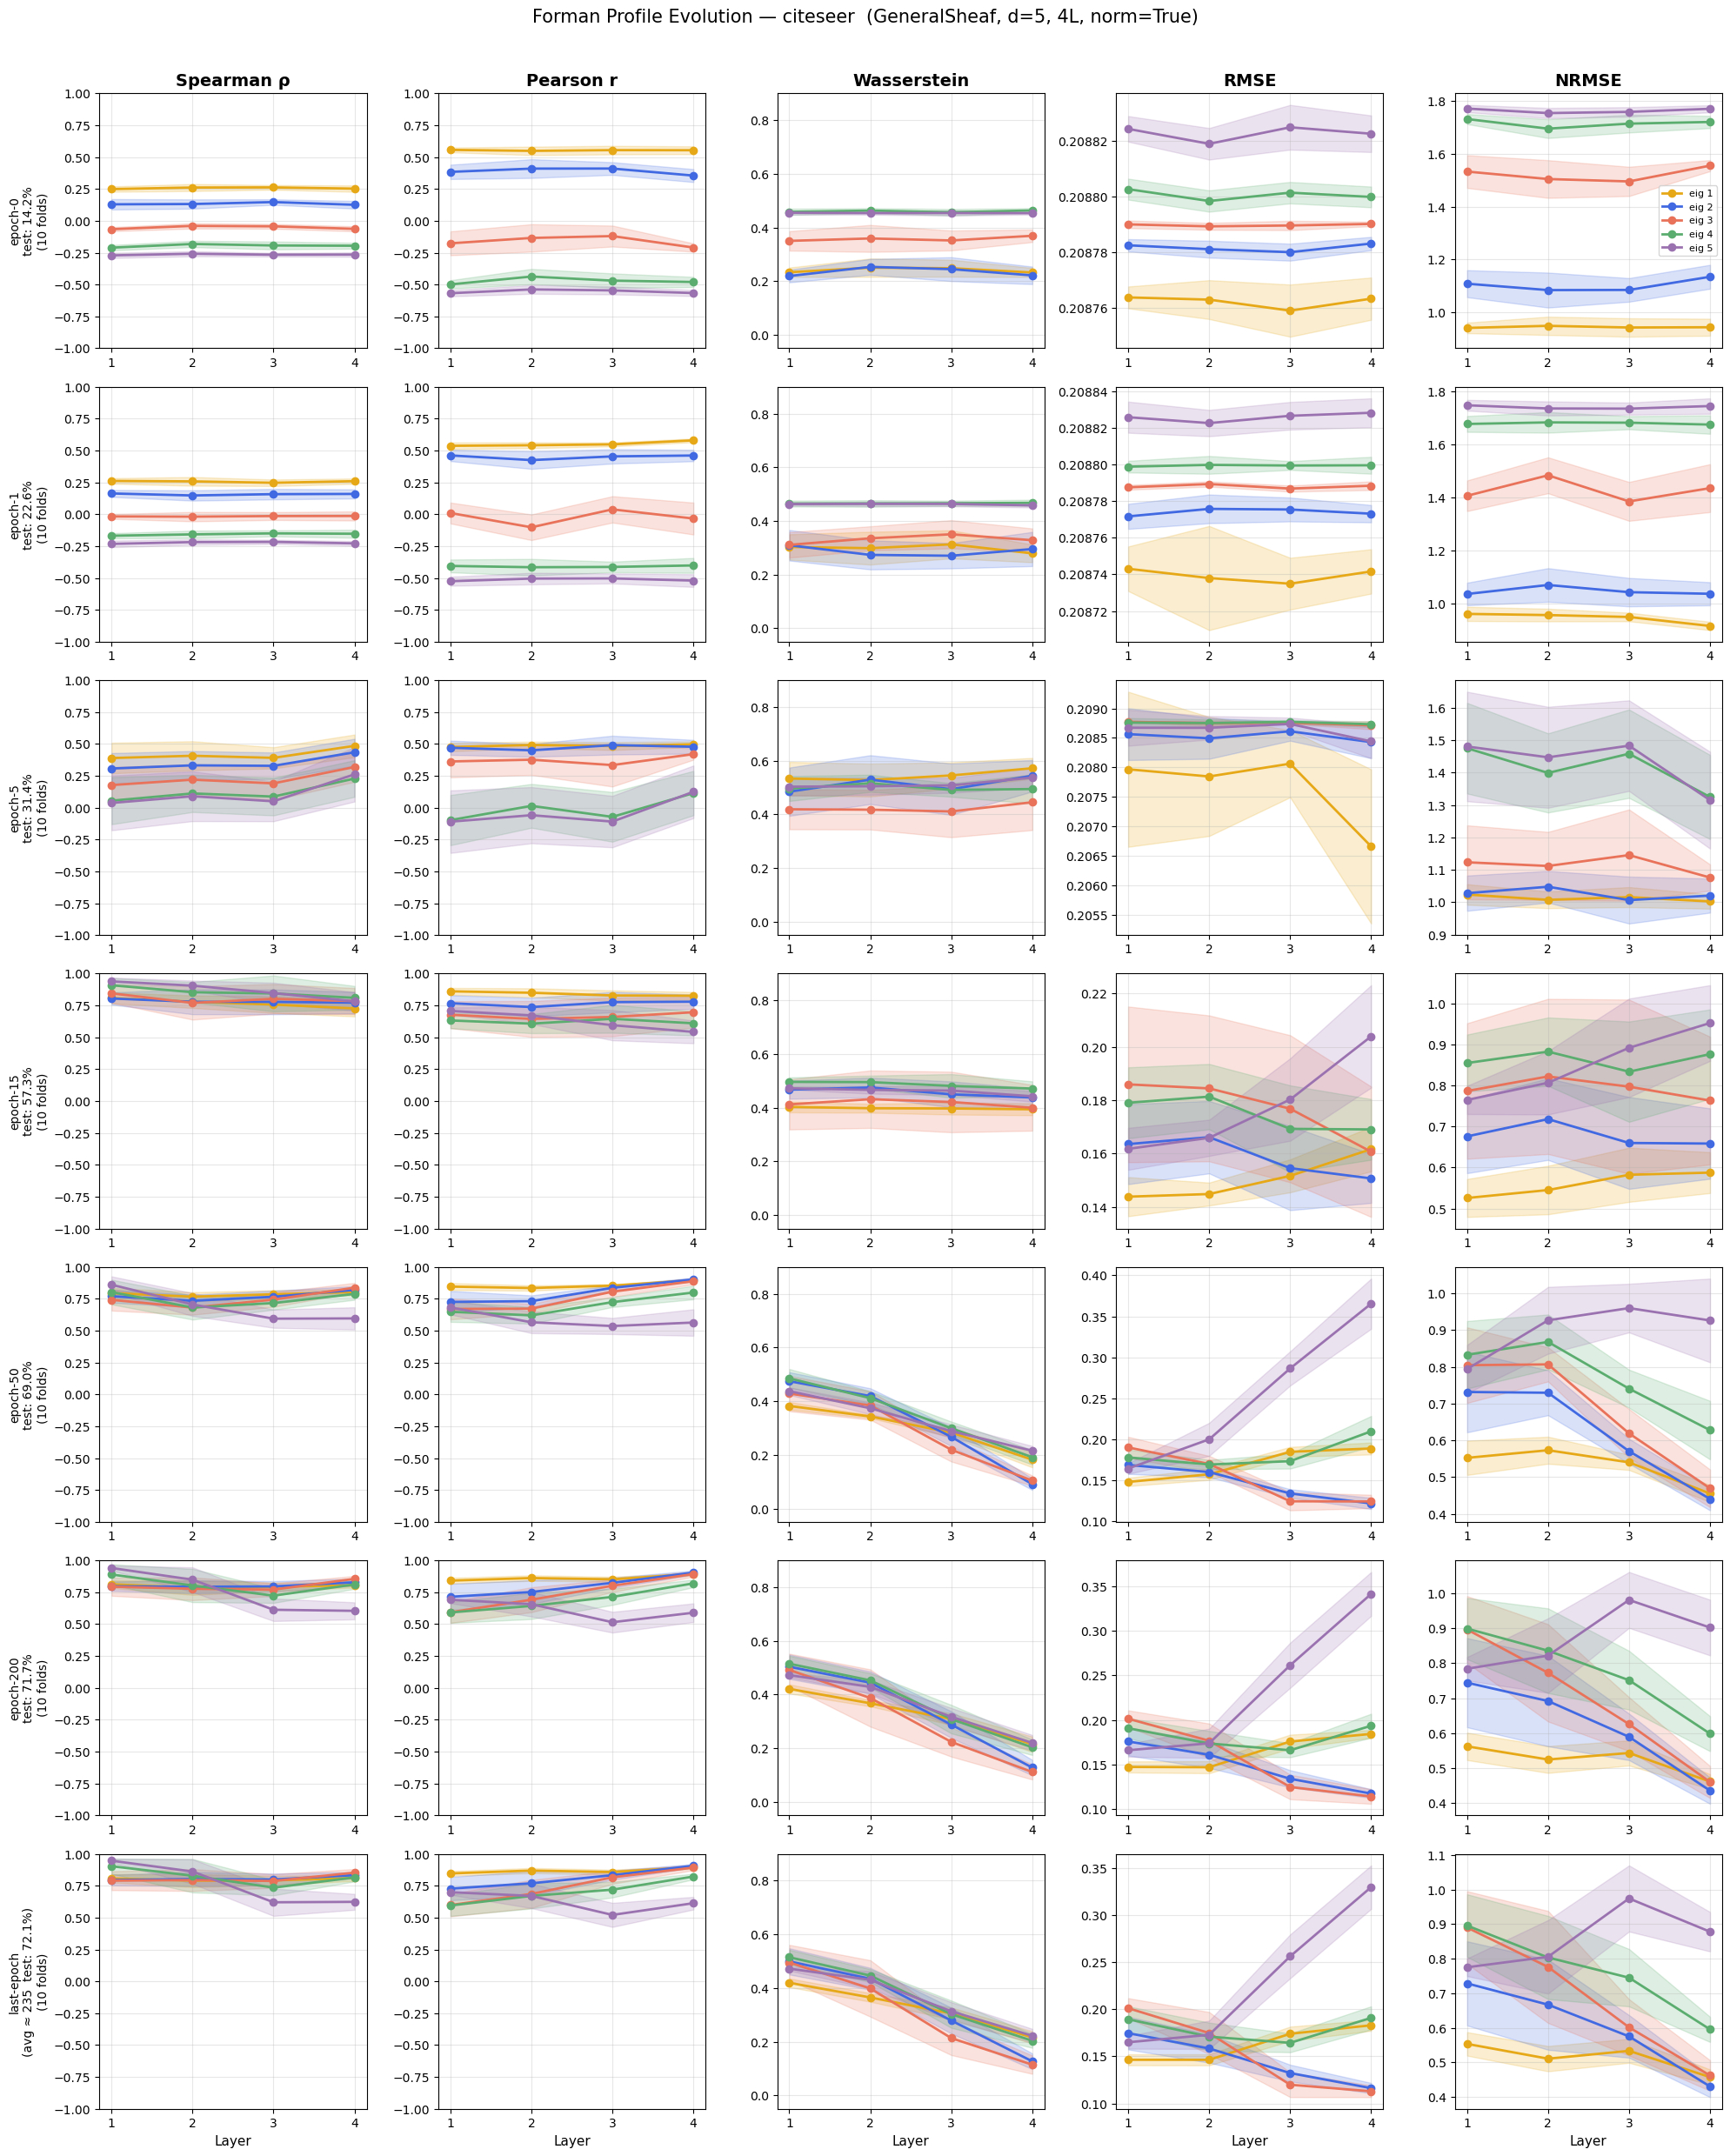

In [8]:
PALETTE = ["#E6A817", "#4169E1", "#E8735A", "#5BAD6F", "#9B72B0",
           "#5BB8C9", "#C97D4E", "#C75B8A"]
colors      = PALETTE[:d]
layer_ticks = np.arange(1, layers + 1)
norm_cap    = normalised.capitalize()

valid = [c for c in checkpoint_names if c in results]
n_rows, n_cols = len(valid), 5

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4 * n_cols, 3.5 * n_rows),
                         squeeze=False)

metric_specs = [
    ('spearman_mean',    'spearman_std',    'Spearman ρ',  (-1, 1)),
    ('pearson_mean',     'pearson_std',     'Pearson r',   (-1, 1)),
    ('wasserstein_mean', 'wasserstein_std', 'Wasserstein', (-0.05, 0.9)),
    ('rmse_mean',        'rmse_std',        'RMSE',        None),
    ('nrmse_mean',       'nrmse_std',       'NRMSE',       None),
]

for row, ckpt_name in enumerate(valid):
    res = results[ckpt_name]
    n_avail = res['n_folds']

    avg_acc, _ = ckpt_acc_stats(ckpt_name)
    acc_str = f"  test: {avg_acc*100:.1f}%" if avg_acc is not None else ""

    if ckpt_name == 'last':
        epoch_vals = []
        for fold_entry in best_epochs_data.values():
            if isinstance(fold_entry, dict):
                ep = fold_entry.get('checkpoints', {}).get('last', {}).get('epoch')
                if ep is not None:
                    epoch_vals.append(float(ep) + 1)
        if epoch_vals:
            row_label = f"last-epoch\n(avg ≈ {np.nanmean(epoch_vals):.0f}{acc_str})"
        else:
            row_label = f"last-epoch{chr(10) + acc_str.strip() if acc_str else ''}"
    else:
        row_label = f"{ckpt_name}{chr(10) + acc_str.strip() if acc_str else ''}"

    for col, (mean_key, std_key, title, ylim) in enumerate(metric_specs):
        ax     = axes[row, col]
        mu_mat = res[mean_key]
        sg_mat = res[std_key]

        for k in range(d):
            mu  = mu_mat[:, k]
            sig = sg_mat[:, k]
            ax.plot(layer_ticks, mu, marker='o', color=colors[k],
                    label=f"eig {k+1}", lw=2)
            ax.fill_between(layer_ticks, mu - sig, mu + sig,
                            alpha=0.2, color=colors[k])

        ax.set_xticks(layer_ticks)
        ax.grid(alpha=0.3)
        if ylim is not None:
            ax.set_ylim(ylim)

        if row == 0:
            ax.set_title(title, fontsize=14, fontweight='bold')
        if row == n_rows - 1:
            ax.set_xlabel("Layer", fontsize=11)
        if col == 0:
            ax.set_ylabel(f"{row_label}\n({n_avail} fold{'s' if n_avail > 1 else ''})",
                          fontsize=10)
        if row == 0 and col == n_cols - 1:
            ax.legend(fontsize=8, loc='best')

fig.suptitle(
    f"Forman Profile Evolution — {dataset}  ({model}, d={d}, {layers}L, norm={norm_cap})",
    fontsize=15, y=1.01
)
fig.tight_layout()
os.makedirs("checkpoint_forman", exist_ok=True)
#plt.savefig(f"checkpoint_forman/{dataset}_{model}_d{d}_{layers}L_Norm_{norm_cap}_checkpoints_evolution.pdf",
            #bbox_inches="tight")
plt.show()

## 7. Heatmap — mean metric across eigenvalues

/tmp/ipykernel_547713/865629596.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


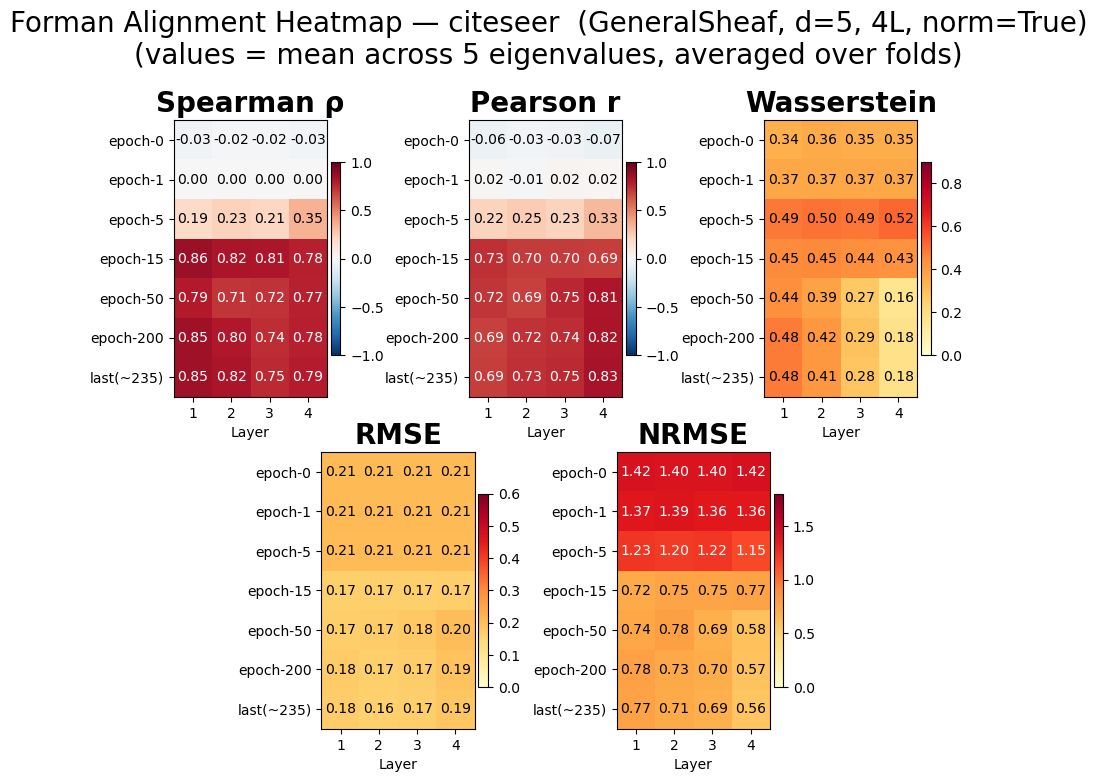

In [26]:
from matplotlib.colors import TwoSlopeNorm
import re as _re2

# ── which checkpoints have results ─────────────────────────────────────────────
valid    = [c for c in checkpoint_names if c in results]
norm_cap = normalised.capitalize()

# ── short y-axis label helper ───────────────────────────────────────────────────
def _short_label(ckpt_name):
    if ckpt_name == 'last':
        epoch_vals = [fe.get('checkpoints', {}).get('last', {}).get('epoch')
                      for fe in best_epochs_data.values() if isinstance(fe, dict)]
        epoch_vals = [float(e) + 1 for e in epoch_vals if e is not None]
        return f"last(~{np.nanmean(epoch_vals):.0f})" if epoch_vals else "last"
    return ckpt_name

y_labels    = [_short_label(c) for c in valid]
layer_ticks = np.arange(1, layers + 1)
n_ckpts     = len(valid)

# ── build (n_ckpts, layers) matrices — mean over eigenvalues ───────────────────
metric_keys = ['spearman_mean', 'pearson_mean', 'wasserstein_mean', 'rmse_mean', 'nrmse_mean']
mats = {}
for key in metric_keys:
    mat = np.full((n_ckpts, layers), np.nan)
    for i, ckpt_name in enumerate(valid):
        mat[i] = results[ckpt_name][key].mean(axis=1)   # mean over d → (layers,)
    mats[key] = mat

# ── layout: GridSpec(2,6) — same pattern as the megaplot ───────────────────────
row_height = max(0.7, 4.0 / n_ckpts)
fig = plt.figure(figsize=(10, row_height * n_ckpts + 3))
gs  = fig.add_gridspec(2, 6, hspace=0.2, wspace=3)

ax_sp  = fig.add_subplot(gs[0, 0:2])   # Spearman
ax_pe  = fig.add_subplot(gs[0, 2:4])   # Pearson
ax_wa  = fig.add_subplot(gs[0, 4:6])   # Wasserstein
ax_rm  = fig.add_subplot(gs[1, 1:3])   # RMSE      (centred)
ax_nr  = fig.add_subplot(gs[1, 3:5])   # NRMSE     (centred)

# (ax, key, title, cmap, vmin, vmax, diverging)
# Fixed vmax for distances = same reference scale as the megaplot line-plots
panels = [
    (ax_sp, 'spearman_mean',    'Spearman ρ',  'RdBu_r', -1,  1,   True),
    (ax_pe, 'pearson_mean',     'Pearson r',   'RdBu_r', -1,  1,   True),
    (ax_wa, 'wasserstein_mean', 'Wasserstein', 'YlOrRd',  0,  0.9, False),
    (ax_rm, 'rmse_mean',        'RMSE',        'YlOrRd',  0,  0.6, False),
    (ax_nr, 'nrmse_mean',       'NRMSE',       'YlOrRd',  0,  1.8, False),
]

for ax, key, title, cmap, vmin, vmax, diverging in panels:
    mat = mats[key]

    if diverging:
        norm_obj = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
        im = ax.imshow(mat, aspect='auto', cmap=cmap, norm=norm_obj, interpolation='nearest')
    else:
        im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')

    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
    ax.set_title(title, fontsize=20, fontweight='bold')
    ax.set_xlabel("Layer", fontsize=10)
    ax.set_xticks(range(layers))
    ax.set_xticklabels(layer_ticks, fontsize=10)
    ax.set_yticks(range(n_ckpts))
    ax.set_yticklabels(y_labels, fontsize=10)

    for i in range(n_ckpts):
        for j in range(layers):
            val = mat[i, j]
            if not np.isnan(val):
                intensity = abs(val) / max(abs(vmin), abs(vmax)) if diverging else val / vmax
                ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                        fontsize=10, color='white' if intensity > 0.6 else 'black')

fig.suptitle(
    f"Forman Alignment Heatmap — {dataset}  ({model}, d={d}, {layers}L, norm={norm_cap})\n"
    f"(values = mean across {d} eigenvalues, averaged over folds)",
    fontsize=20, y=1.02,
)
fig.tight_layout()
# plt.savefig(f"checkpoint_forman/{dataset}_{model}_d{d}_{layers}L_Norm_{norm_cap}_heatmap.pdf", bbox_inches="tight")
plt.show()

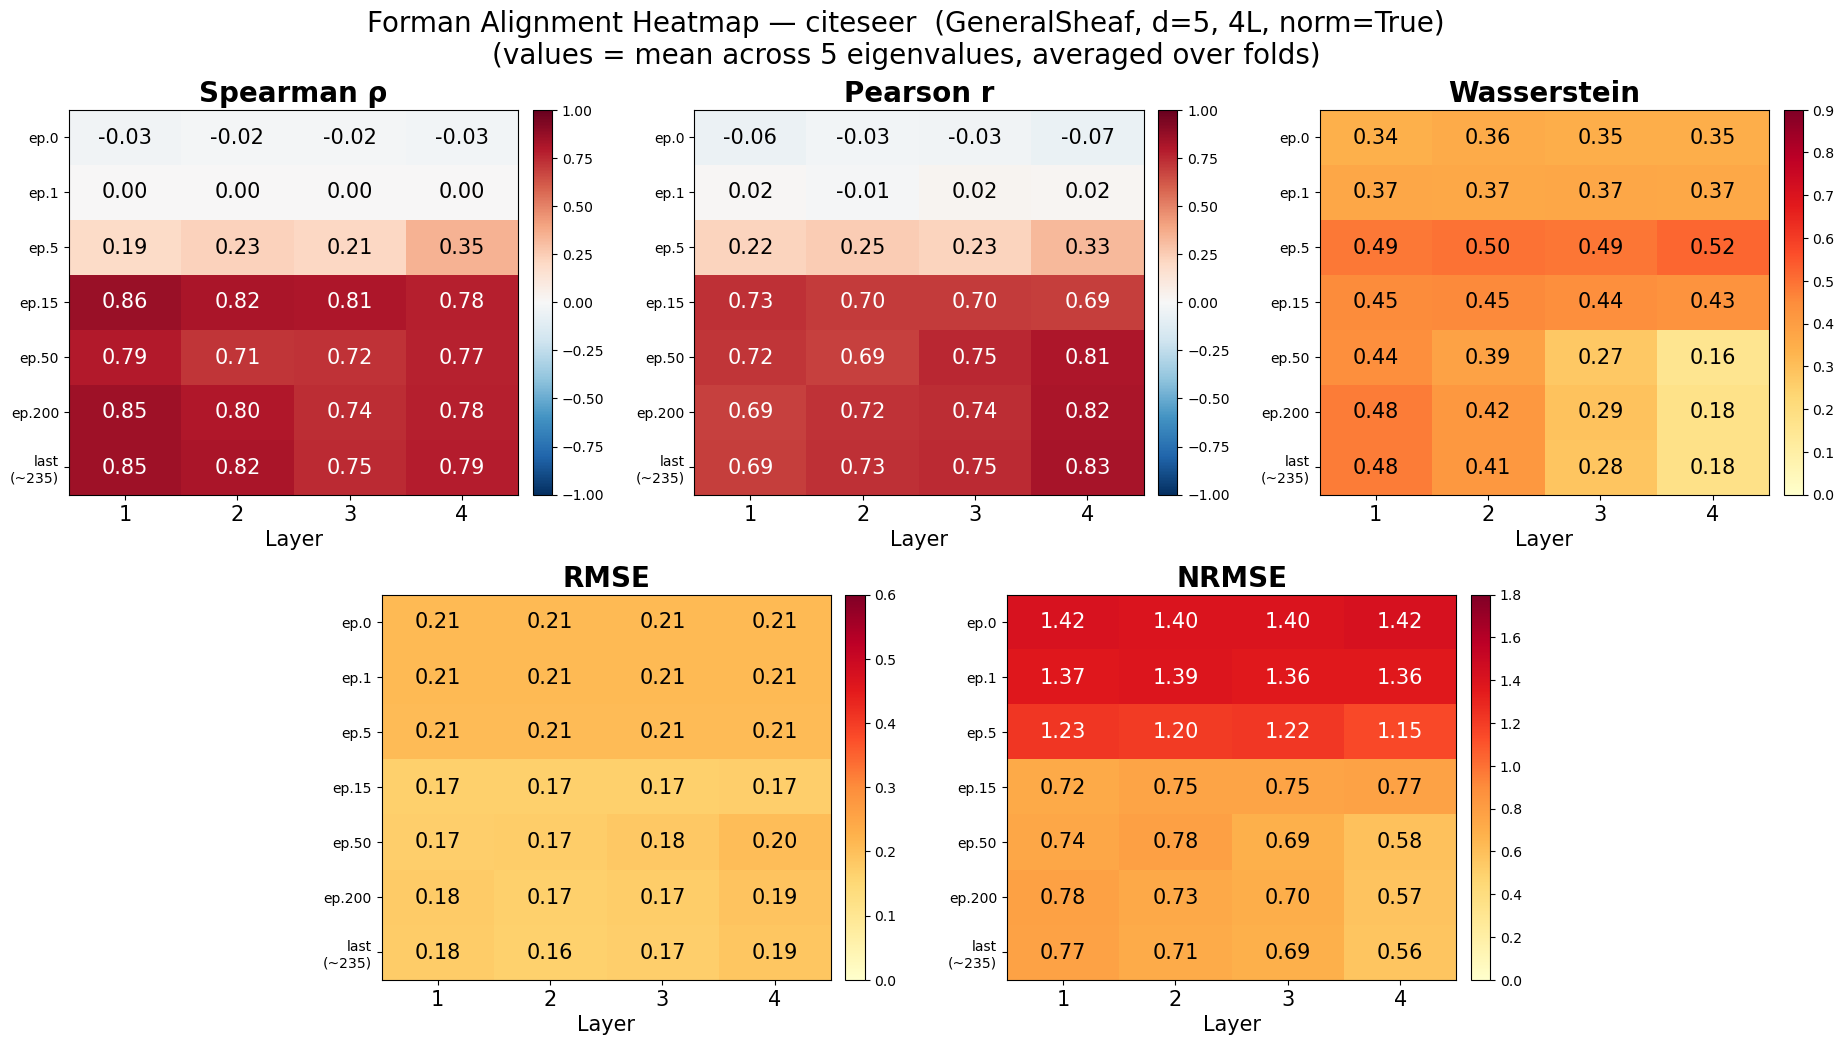

In [32]:
from matplotlib.colors import TwoSlopeNorm
import re as _re2

# ── which checkpoints have results ─────────────────────────────────────────────
valid    = [c for c in checkpoint_names if c in results]
norm_cap = normalised.capitalize()

# ── short y-axis label  (epoch-5 → ep.5,  last stays compact) ─────────────────
def _short_label(ckpt_name):
    if ckpt_name == 'last':
        epoch_vals = [fe.get('checkpoints', {}).get('last', {}).get('epoch')
                      for fe in best_epochs_data.values() if isinstance(fe, dict)]
        epoch_vals = [float(e) + 1 for e in epoch_vals if e is not None]
        return f"last\n(~{np.nanmean(epoch_vals):.0f})" if epoch_vals else "last"
    m = _re2.match(r'epoch-(\d+)', ckpt_name)
    return f"ep.{m.group(1)}" if m else ckpt_name

y_labels    = [_short_label(c) for c in valid]
layer_ticks = np.arange(1, layers + 1)
n_ckpts     = len(valid)

# ── build (n_ckpts, layers) matrices — mean over eigenvalues ───────────────────
metric_keys = ['spearman_mean', 'pearson_mean', 'wasserstein_mean', 'rmse_mean', 'nrmse_mean']
mats = {}
for key in metric_keys:
    mat = np.full((n_ckpts, layers), np.nan)
    for i, ckpt_name in enumerate(valid):
        mat[i] = results[ckpt_name][key].mean(axis=1)
    mats[key] = mat

# ── layout: size driven by actual cell count, not guesswork ───────────────────
cell_h  = 0.55          # height per checkpoint row (inches)
cell_w  = 0.90          # width per layer column (inches)
panel_w = layers * cell_w
panel_h = n_ckpts * cell_h
gap     = 3         # horizontal gap between panels (inches)
left_m  = 0.9 ; right_m = 0.3
top_m   = 1.0 ; bot_m   = 0.6

fig_w = left_m + 3 * panel_w + 2 * gap + 3 * 0.18 + right_m   # 0.18 per colorbar
fig_h = top_m  + 2 * panel_h + 1.0 + bot_m                     # 1.0 vertical gap

fig = plt.figure(figsize=(fig_w, fig_h))
gs  = fig.add_gridspec(2, 6,
                       left=left_m/fig_w, right=1-right_m/fig_w,
                       top=1-top_m/fig_h, bottom=bot_m/fig_h,
                       hspace=1.0/panel_h,
                       wspace=gap/panel_w)

ax_sp = fig.add_subplot(gs[0, 0:2])
ax_pe = fig.add_subplot(gs[0, 2:4])
ax_wa = fig.add_subplot(gs[0, 4:6])
ax_rm = fig.add_subplot(gs[1, 1:3])
ax_nr = fig.add_subplot(gs[1, 3:5])

panels = [
    (ax_sp, 'spearman_mean',    'Spearman ρ',  'RdBu_r', -1,  1,   True),
    (ax_pe, 'pearson_mean',     'Pearson r',   'RdBu_r', -1,  1,   True),
    (ax_wa, 'wasserstein_mean', 'Wasserstein', 'YlOrRd',  0,  0.9, False),
    (ax_rm, 'rmse_mean',        'RMSE',        'YlOrRd',  0,  0.6, False),
    (ax_nr, 'nrmse_mean',       'NRMSE',       'YlOrRd',  0,  1.8, False),
]

for ax, key, title, cmap, vmin, vmax, diverging in panels:
    mat = mats[key]
    if diverging:
        norm_obj = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
        im = ax.imshow(mat, aspect='auto', cmap=cmap, norm=norm_obj, interpolation='nearest')
    else:
        im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')

    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
    ax.set_title(title, fontsize=20, fontweight='bold', pad=6)
    ax.set_xlabel("Layer", fontsize=15)
    ax.set_xticks(range(layers))
    ax.set_xticklabels(layer_ticks, fontsize=15)
    ax.set_yticks(range(n_ckpts))
    ax.set_yticklabels(y_labels, fontsize=10)

    for i in range(n_ckpts):
        for j in range(layers):
            val = mat[i, j]
            if not np.isnan(val):
                intensity = abs(val) / max(abs(vmin), abs(vmax)) if diverging else val / vmax
                ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                        fontsize=15, color='white' if intensity > 0.6 else 'black')

fig.suptitle(
    f"Forman Alignment Heatmap — {dataset}  ({model}, d={d}, {layers}L, norm={norm_cap})\n"
    f"(values = mean across {d} eigenvalues, averaged over folds)",
    fontsize=20, y=1.0,
)
# plt.savefig(f"checkpoint_forman/{dataset}_{model}_d{d}_{layers}L_Norm_{norm_cap}_heatmap.pdf", bbox_inches="tight")
plt.show()
